## 1



# (a)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("~/shared/data/US_births_2000-2014.csv")

If births occur at the same rate year-round, then any given day of the week will account for 1/7 of the births and for any month it will account for 1/12 of the births

## (b)

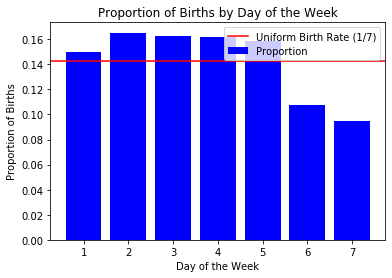

In [3]:
births_per_day = df.groupby('day_of_week')['births'].sum()
total = births_per_day.sum()

proportion = births_per_day / total


plt.bar(proportion.index, proportion.values, color = 'blue', label = 'Proportion')


plt.axhline(1 /7, color='red', label = 'Uniform Birth Rate (1/7)')

plt.xlabel('Day of the Week')
plt.ylabel('Proportion of Births')
plt.title('Births by Day of the Week')
plt.legend()
plt.show()

The empirical proportions do not match the theoretical line, you can see in the data that on weekends there tends to be fewer births, this could be due to cultural factors or hospital policies

## (c)

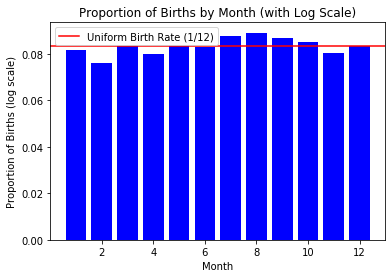

In [4]:
births_per_month = df.groupby('month')['births'].sum()
birth_total = births_per_month.sum()
birth_proportion = births_per_month / total

plt.bar(birth_proportion.index, birth_proportion.values, color='blue')

plt.axhline(1 / 12, color='red', label='Uniform Birth Rate (1/12)')

plt.xlabel('Month')
plt.ylabel('Proportion of Births')
plt.title('Births by Month')
plt.legend()
plt.show()


The empirical proportions don't match the theoretical line, because months in the summer are above the theoretical line and the first four months on average are below the line. This could be due to seasonal factors.

## (d)

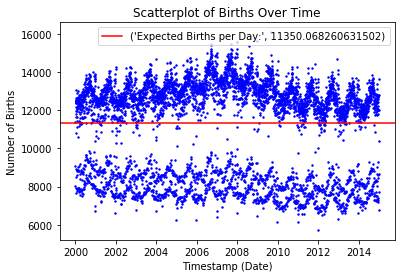

In [10]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
plt.scatter(df['timestamp'], df['births'], color='blue')

total_births = df['births'].sum()
days = (df['timestamp'].max() - df['timestamp'].min()).days + 1  
expected_births = total_births / days

plt.axhline(expected_births, color='red', label=('Expected Births per Day:', expected_births))

plt.xlabel('Date')
plt.ylabel('Number of Births')
plt.title('Births Over Time')
plt.legend()
plt.show()

## (e)

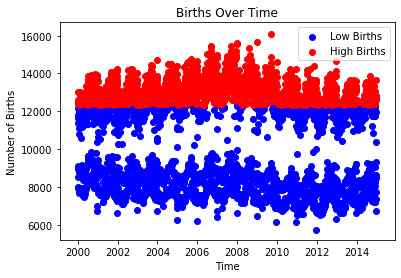

In [13]:

df['timestamp'] = pd.to_datetime(df['timestamp'])
threshold = df['births'].median()

low = df[df['births'] <= threshold]
high = df[df['births'] > threshold]

plt.scatter(low['timestamp'], low['births'], color='blue', label='Low Births')
plt.scatter(high['timestamp'], high['births'], color='red', label='High Births')

plt.xlabel('Time')
plt.ylabel('Number of Births')
plt.title('Births Over Time')
plt.legend()
plt.show()


## (f)

Over times, there could be seasonal issues or patterens that affect the birth rate, such as holidays.

# 2

## (a)

In [54]:
df = pd.read_csv("~/shared/data/framingham.csv")
print(df.head(5))

   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2 

## (b)

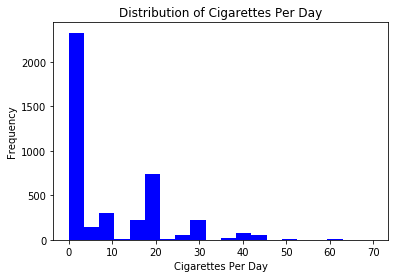

In [28]:
plt.hist(df['cigsPerDay'], bins=20, color='blue',)
plt.title('Distribution of Cigarettes Per Day')
plt.xlabel('Cigarettes Per Day')
plt.ylabel('Frequency')
plt.show()


The histogram shows a right skew

## (c)

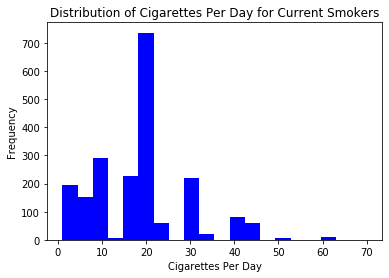

In [30]:
current_smokers = df[df['currentSmoker'] == 1]
plt.hist(current_smokers['cigsPerDay'], bins=20, color='blue')
plt.title('Distribution of Cigarettes Per Day for Current Smokers')
plt.xlabel('Cigarettes Per Day')
plt.ylabel('Frequency')
plt.show()

Comparing the two graphs, we can see that the skew on the graph in part c is closer to a zero skew, the average for part c would be around 20 and for part be it would be closer to 0. Changing those who are represented in each graph shifted the data towards more cigarettes per day

## (d)

In [31]:
cigs_summary = {
    'Number of observations': df['cigsPerDay'].count(),
    'Mean': round(df['cigsPerDay'].mean(), 1),
    'Median': df['cigsPerDay'].median(),
    'Maximum': df['cigsPerDay'].max(),
    'Standard Deviation': round(df['cigsPerDay'].std(), 1)
}
print(cigs_summary)

{'Number of observations': 4211, 'Mean': 9.0, 'Median': 0.0, 'Maximum': 70.0, 'Standard Deviation': 11.9}


## (e)

If we had a typo of 300 instead of 30, it would increase the mean because the mean is affected by larger outliers, the median wouldn't be as affected since it doesn't rely much on outliers and the standard deviation would increase since the data is much more spread out 

## (f)

In [41]:
sample_cigs = df['cigsPerDay'].sample(100)
sample_mean = round(sample_cigs.mean(), 2)
print('Sample Mean of 100 observations:', sample_mean)



Sample Mean of 100 observations: 8.08


## (g)

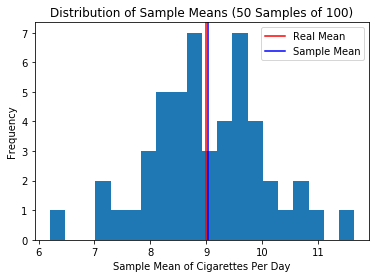

In [59]:
sample_means_50 = [df['cigsPerDay'].sample(100).mean() for i in range(50)]

plt.hist(sample_means_50, bins=20)


true_mean = df['cigsPerDay'].mean()
plt.axvline(true_mean, color='red', label='Real Mean')


sample_means = sum(sample_means_50) / len(sample_means_50)
plt.axvline(sample_means, color='blue', label='Sample Mean')

plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean of Cigarettes Per Day')
plt.ylabel('Frequency')
plt.legend()
plt.show()


## 

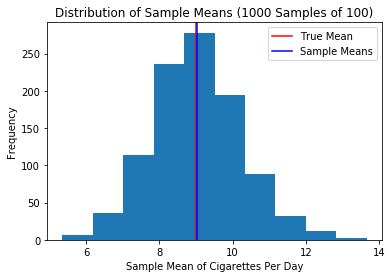

In [67]:
sample_1000 = [df['cigsPerDay'].sample(100).mean() for i in range(1000)]
plt.hist(sample_1000,)
plt.axvline(true_mean, color='red', label='True Mean')
sample_means_1000 = sum(sample_1000) / (len(sample_1000))
plt.axvline(sample_means_1000, color='blue', label='Sample Means')

plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean of Cigarettes Per Day')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## (i)

Based on my data the mean for both 100 and 1000 stayed roughly the same at 9

## (j)

The shape of the sampling distribution as the number of samples increases tend to become more bell shaped compared to when there were fewer samples it was more bimodal

## (k)

The Central Limit Theorem states that if the sample size increases, then the distribution will follow a normal distribution which we can see based on the two bar charts


# 3

## (a)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("~/shared/data/federalist-papers/all_word_counts.csv")
print(df.columns[:5])
print(df.columns[-5:])

Index(['from', 'the', 'more', 'general', 'inquiries'], dtype='object')
Index(['Essay', 'Author', 'Publication', 'Date', 'total_word_count'], dtype='object')


## (b)

In [10]:
authors = df["Author"].unique()
author_word_count = df.groupby('Author')['total_word_count'].apply(list)
print(authors)
print(author_word_count)


['Unknown' 'Hamilton' 'Madison' 'Jay' 'Hamilton and Madison']
Author
Hamilton                [1637.0, 1992.0, 2245.0, 1975.0, 1961.0, 1482....
Hamilton and Madison                             [2014.0, 1503.0, 2083.0]
Jay                              [1635.0, 1336.0, 2304.0, 1659.0, 1439.0]
Madison                 [2083.0, 2733.0, 2712.0, 2117.0, 2775.0, 3421....
Unknown                 [1841.0, 1994.0, 1627.0, 2157.0, 2204.0, 2031....
Name: total_word_count, dtype: object


The first line of code gets the names of all the authors and the second line will group the word count for each author into a list

## (c)

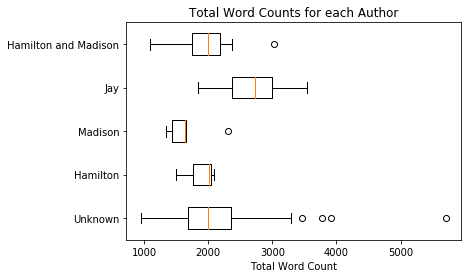

In [11]:
plt.boxplot(author_word_count, vert=False, labels=authors)


plt.xlabel('Total Word Count')
plt.title('Total Word Counts for each Author')

# Display the plot
plt.show()

## (d)

In [12]:
import numpy as np
fav_author = "Hamilton"
filtered = df[df['Author'] == fav_author]
count = filtered.iloc[:, :-5].sum()
total = count.sum()
rel_freq = count / total
words = rel_freq.index  
sampled_words = np.random.choice(words, size=250, p=rel_freq)

essay = " ".join(sampled_words)
print(essay)

of departments or governor all the never the article of of of do independence a treasure in rule from great so either and a greater conclusion a of room the and the peace us provision public that be particular of they an of the contain that debts several expressly discern which any such if the their this is they states the much so perhaps let the establish impending laying the of benefit view is of it to upon an correct for a general the deem constitution if accessible parted audience deserve practice national trivial interest the this will than mean mean dissolved not of alluded industry with and have with other a contribute which aphorisms even government objects to their itself but that as who or ambitious immediate to of of proper inevitable master and effects can in the evidently where not by up description measure be of they be from institution to intention and them intervention magistrate would which encroachments the of require the the a fifteen ambition former moderation i and

This is not a realistic essay, it because it doesn't follow proper grammar  or even make sense

# 4

## (a)

Replacement means that after a ticket is selected, that ticket is placed back into the bucket holding all the other tickets. The probability that the lottery outcome results in $300 to one person is 1 / 1,000,000 (1/100 X 1/100 X 1/100)

## (b)

If we assume there is replacement, then we get a probability of 2.97$ (1 - 99/100 ^3)

## (c)

If there is no replacement, then a person can only win once so the probability of winning 100$ in 3/100 or 3%

## (d)

(1/100) x (1/99) x (1/98) = 1 / (970200)

## (e)

The expected winnings per ticket are the same for both since the number of tickets and prize money stays the same

## (f)

The law of large number states that as the sample size grows, the mean get closer to the average of the whole population, so overtime your average profit per entry would be -1